In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson
import qutip as qt

In [2]:
N = 20  # Fock space dimention

# Inicial states of the hilbert space
psi_plus  = qt.coherent(N, 1.0)   #|+alpha>
psi_minus = qt.coherent(N, -1.0)  #  |-alpha>


beta = 1.0    #beta=1 (in alpha units, so it's the same as summing alpha)
D = qt.displace(N, beta) #Displacement operator 

state0_shifted = D * psi_minus  # Applying the displacement operator, getting the vaccum state |0>
state1_shifted = D * psi_plus   # |2.0>

n_op = qt.num(N) #number operator

mean_value_minus = qt.expect(n_op, state0_shifted)   #expected value for each state
mean_value_plus  = qt.expect(n_op, state1_shifted)

n = np.arange(0, 10)
P_n_given_bit0 = poisson.pmf(n, mean_value_minus) #Poisson distribution
P_n_given_bit1 = poisson.pmf(n, mean_value_plus)

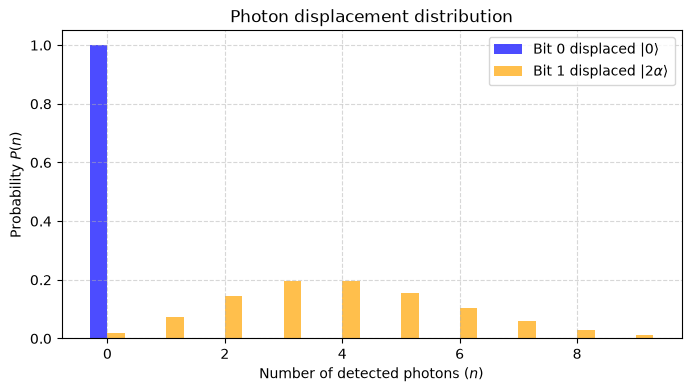

In [11]:
plt.figure(figsize=(8, 4))
plt.bar(n - 0.15, P_n_given_bit0, width=0.3, color='blue', alpha=0.7, label=r'Bit 0 displaced $|0\rangle$')
plt.bar(n + 0.15, P_n_given_bit1, width=0.3, color='orange', alpha=0.7, label=r'Bit 1 displaced $|2\alpha\rangle$')

plt.xlabel('Number of detected photons ($n$)')
plt.ylabel(r'Probability $P(n)$') 
plt.title('Photon displacement distribution')
plt.legend()    
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

**Kennedy Error**

In [ ]:
P_bit0 = 0.5  #assuming they have 50/50 probability of happening each
P_bit1 = 0.5

# Error for Bit 0: detecting n > 0 photons (false alarm)
P_error_given_bit0 = np.sum(P_n_given_bit0[n > 0])  

# Error given Bit 1: detecting n = 0 photons (not detecting anything)
P_error_given_bit1 = P_n_given_bit1[0]

P_error_sim = P_bit0 * P_error_given_bit0 + P_bit1 * P_error_given_bit1  #Total error probability

alpha_val = 1.0
P_error_exact = 0.5 * np.exp(-4 * (alpha_val**2))   #analytical error value with the poisson P_error(n=0) = 0.5 * exp(-4 * |alpha|^2)

print(f"P(Error | Bit 0) = {P_error_given_bit0:.6e}")
print(f"P(Error | Bit 1) = {P_error_given_bit1:.6e}")
print("-" * 40)
print(f"Total error probability (Numerical) : {P_error_sim:.6e}")
print(f"Total error probability (Analytical): {P_error_exact:.6e}")

P(Error | Bit 0) = 4.515734e-32
P(Error | Bit 1) = 1.831564e-02
----------------------------------------
Total error probability (Numerical) : 9.157820e-03
Total error probability (Analytical): 9.157819e-03


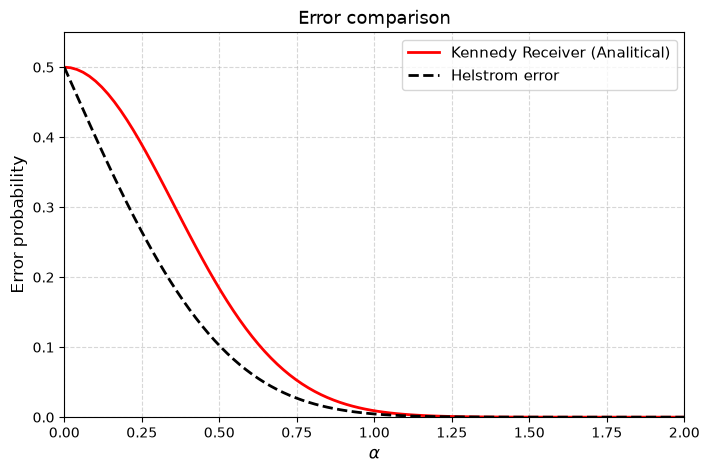

In [22]:
alphas = np.linspace(0, 2.0, 100)  #alpha amplitudes

P_err_kennedy = 0.5 * np.exp(-4 * (alphas**2))  # Analitical error probability of the Kennedy
P_err_helstrom = 0.5 * (1.0 - np.sqrt(1.0 - np.exp(-4 * (alphas**2))))   #theoredical error helstrom

plt.figure(figsize=(8, 5))
plt.plot(alphas, P_err_kennedy, 'r-', linewidth=2, label='Kennedy Receiver (Analitical)')
plt.plot(alphas, P_err_helstrom, 'k--', linewidth=2, label='Helstrom error')

plt.xlabel(r'$\alpha$', fontsize=12)
plt.ylabel(r'Error probability', fontsize=12)
plt.title('Error comparison', fontsize=13)
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend(fontsize=11)
plt.ylim([0, 0.55])
plt.xlim([0,2])
plt.show()

We can conclude that for our quantum bound Helstrom error, the error probability follow the path of the curve above. For the Kennedy receiver, it's not as perfect as the helstrom ofc but it still has a low error probability when comparing to the theoredical limit one.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt

N = 15                
alpha = 1.0            # State |alpha>    
T = 0.99       # High Transmittance to simulate the Beam Splitter
R = 1.0 - T           # Reflectivity

# LOCAL OSCILLATOR:
# Queremos que: sqrt(T)*(-alpha) + sqrt(R)*beta_lo = 0  =>  beta_lo = sqrt(T/R)*alpha
beta_lo = np.sqrt(T / R) * alpha

# 3. Estados de Entrada a 2 Modos: tensor(Sinal, LO)
# Bit 0: |-alpha> , Bit 1: |+alpha>
psi_sig_0 = qt.coherent(N, -alpha)
psi_sig_1 = qt.coherent(N,  alpha)
psi_lo    = qt.coherent(N,  beta_lo)

in_state_bit0 = qt.tensor(psi_sig_0, psi_lo)
in_state_bit1 = qt.tensor(psi_sig_1, psi_lo)

# 4. Operador do Beam Splitter (2 modos)
# Ângulo theta do BS: cos(theta) = sqrt(T), sin(theta) = sqrt(R)
theta = np.arccos(np.sqrt(T))
U_BS = qt.beamsplitter(N, N, theta=theta)

# 5. Estados após o Beam Splitter
out_state_bit0 = U_BS * in_state_bit0
out_state_bit1 = U_BS * in_state_bit1

# 6. Modo que vai para o detetor de fotões (traço parcial sobre o modo auxiliar/LO)
# O modo 0 é a saída do sinal deslocado
rho_det_bit0 = out_state_bit0.ptrace(0)
rho_det_bit1 = out_state_bit1.ptrace(0)

# 7. Distribuição de Fotões no Detetor (diagonal da matriz de densidade)
p_n_det_bit0 = np.real(rho_det_bit0.diag())
p_n_det_bit1 = np.real(rho_det_bit1.diag())

print(f"Probabilidade de vácuo para Bit 0 (P(n=0 | bit 0)): {p_n_det_bit0[0]:.4f}")
print(f"Probabilidade de vácuo para Bit 1 (P(n=0 | bit 1)): {p_n_det_bit1[0]:.4f}")

AttributeError: module 'qutip' has no attribute 'beamsplitter'